<a href="https://colab.research.google.com/github/rgligora/ai-ml/blob/main/Train_Compartment_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Compartment Detection Model — Unlokie CV Pipeline

**Stage 2 of 3** in the Unlokie CV pipeline: detect TOP / MIDDLE / BOTTOM compartments inside a locker crop produced by the Stage 1 locker detector.

| Parameter | Value |
|---|---|
| Model | YOLO11n (nano — input is already a tight locker crop) |
| Classes | 3 — `BOTTOM`, `MIDDLE`, `TOP` |
| Dataset | `compartment_v0_1` (61 train / 7 val) |
| Epochs | 100 |
| Resolution | 640 × 640 |

## 1. Verify GPU

In [1]:
!nvidia-smi

Thu May  7 21:46:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Load Dataset from Google Drive

Upload `compartment_v0_1.zip` to your Google Drive, then run the cell below.
Update the path if you placed the zip in a subfolder.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/unlokie-cv/compartment_v0_1.zip /content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
# Unzip — the archive already contains train/validation splits and data.yaml
!unzip -q /content/compartment_v0_1.zip -d /content
!echo 'Train images:' && ls /content/data/train/images | wc -l
!echo 'Val images:'   && ls /content/data/validation/images | wc -l
!cat /content/data.yaml

Train images:
61
Val images:
7
path: /content/data
train: train/images
val: validation/images
nc: 3
names:
  0: BOTTOM
  1: MIDDLE
  2: TOP


## 3. Install Ultralytics

In [5]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.8 MB/s eta 0:00:00


## 4. Train

Using **YOLO11n** (nano) — the compartment model receives tight locker crops (~640 px tall after letterbox), so a nano model is sufficient and keeps inference fast on ARM64 production hardware.

`patience=30` stops early if validation mAP stops improving.

In [6]:
!yolo detect train \
    data=/content/data.yaml \
    model=yolo11n.pt \
    epochs=100 \
    imgsz=640 \
    patience=30 \
    project=/content/runs \
    name=compartment_v0_1

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

## 5. Review Training Results

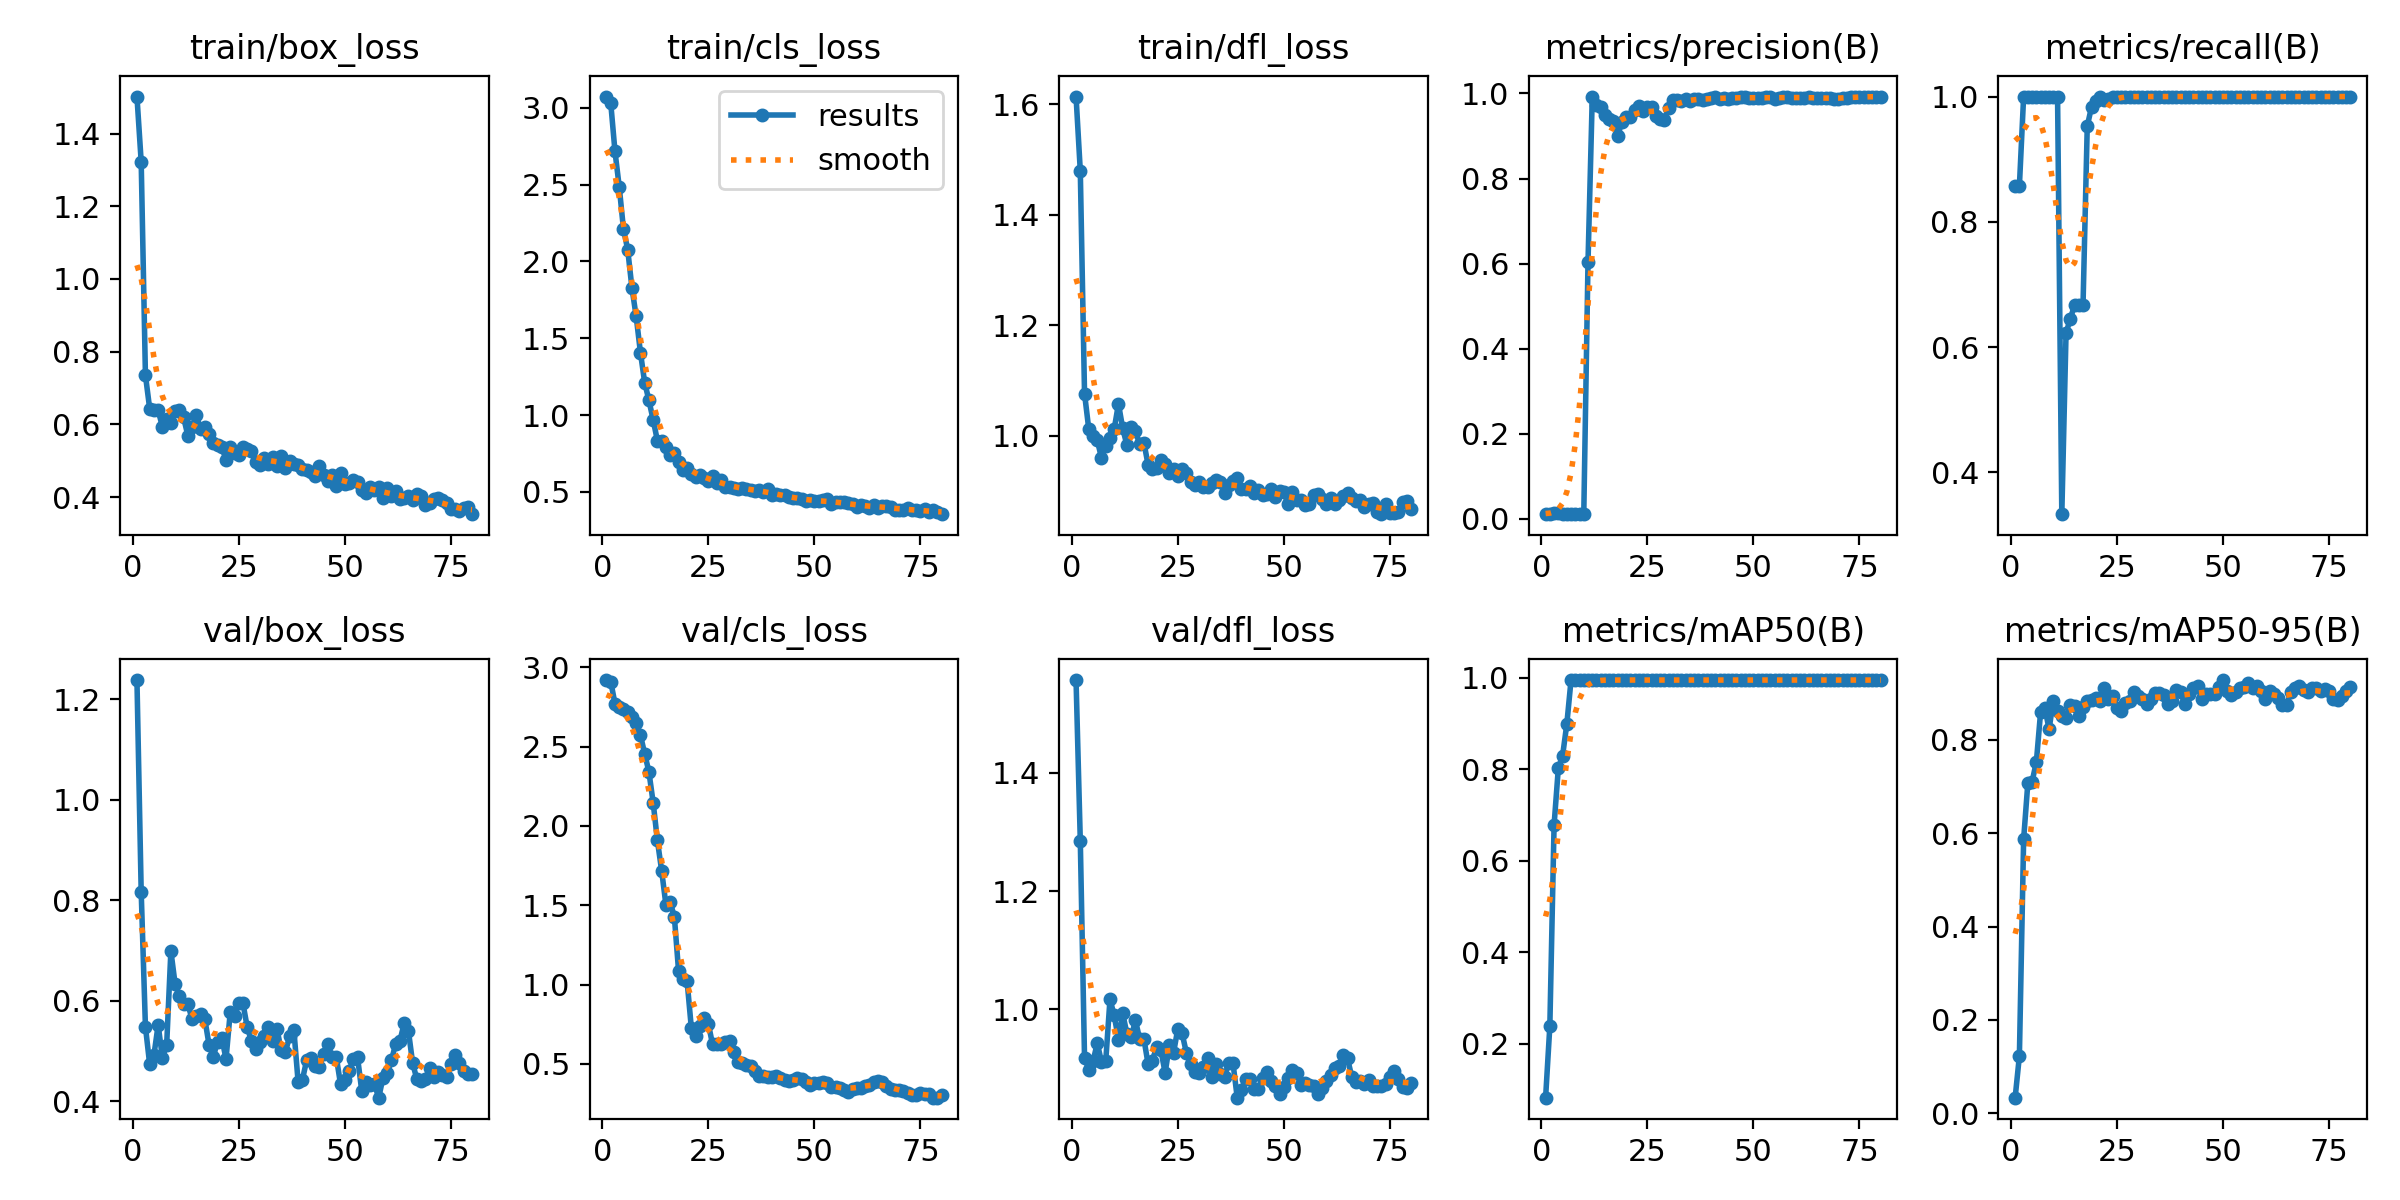

In [7]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/runs/compartment_v0_1/results.png'))

## 6. Test on Validation Images

In [8]:
!yolo detect predict \
    model=/content/runs/compartment_v0_1/weights/best.pt \
    source=/content/data/validation/images \
    save=True \
    project=/content/runs \
    name=compartment_v0_1_val_predict

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/7 /content/data/validation/images/172f85f3-81d8-495e-a824-9a7ebfe95189.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 51.3ms
image 2/7 /content/data/validation/images/29f723db-cfcf-461b-bd0c-26e8bd5801f3.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 8.4ms
image 3/7 /content/data/validation/images/4101e24b-ba96-45ab-baa8-e037871da449.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 8.0ms
image 4/7 /content/data/validation/images/74e07669-0784-4756-b27a-c85a705eac0a.jpg: 640x224 1 BOTTOM, 1 MIDDLE, 1 TOP, 49.8ms
image 5/7 /content/data/validation/images/82a0b3db-788a-45ec-8216-a37529059887.jpg: 640x224 1 BOTTOM, 1 MIDDLE, 1 TOP, 7.9ms
image 6/7 /content/data/validation/images/92ba9449-7d9a-4d57-ba19-3ad6e69536dc.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 8.2ms
image 7/7 /content/data/validation/images/c7227055-2ea0-4928-9e59-06589cc72c62.jp

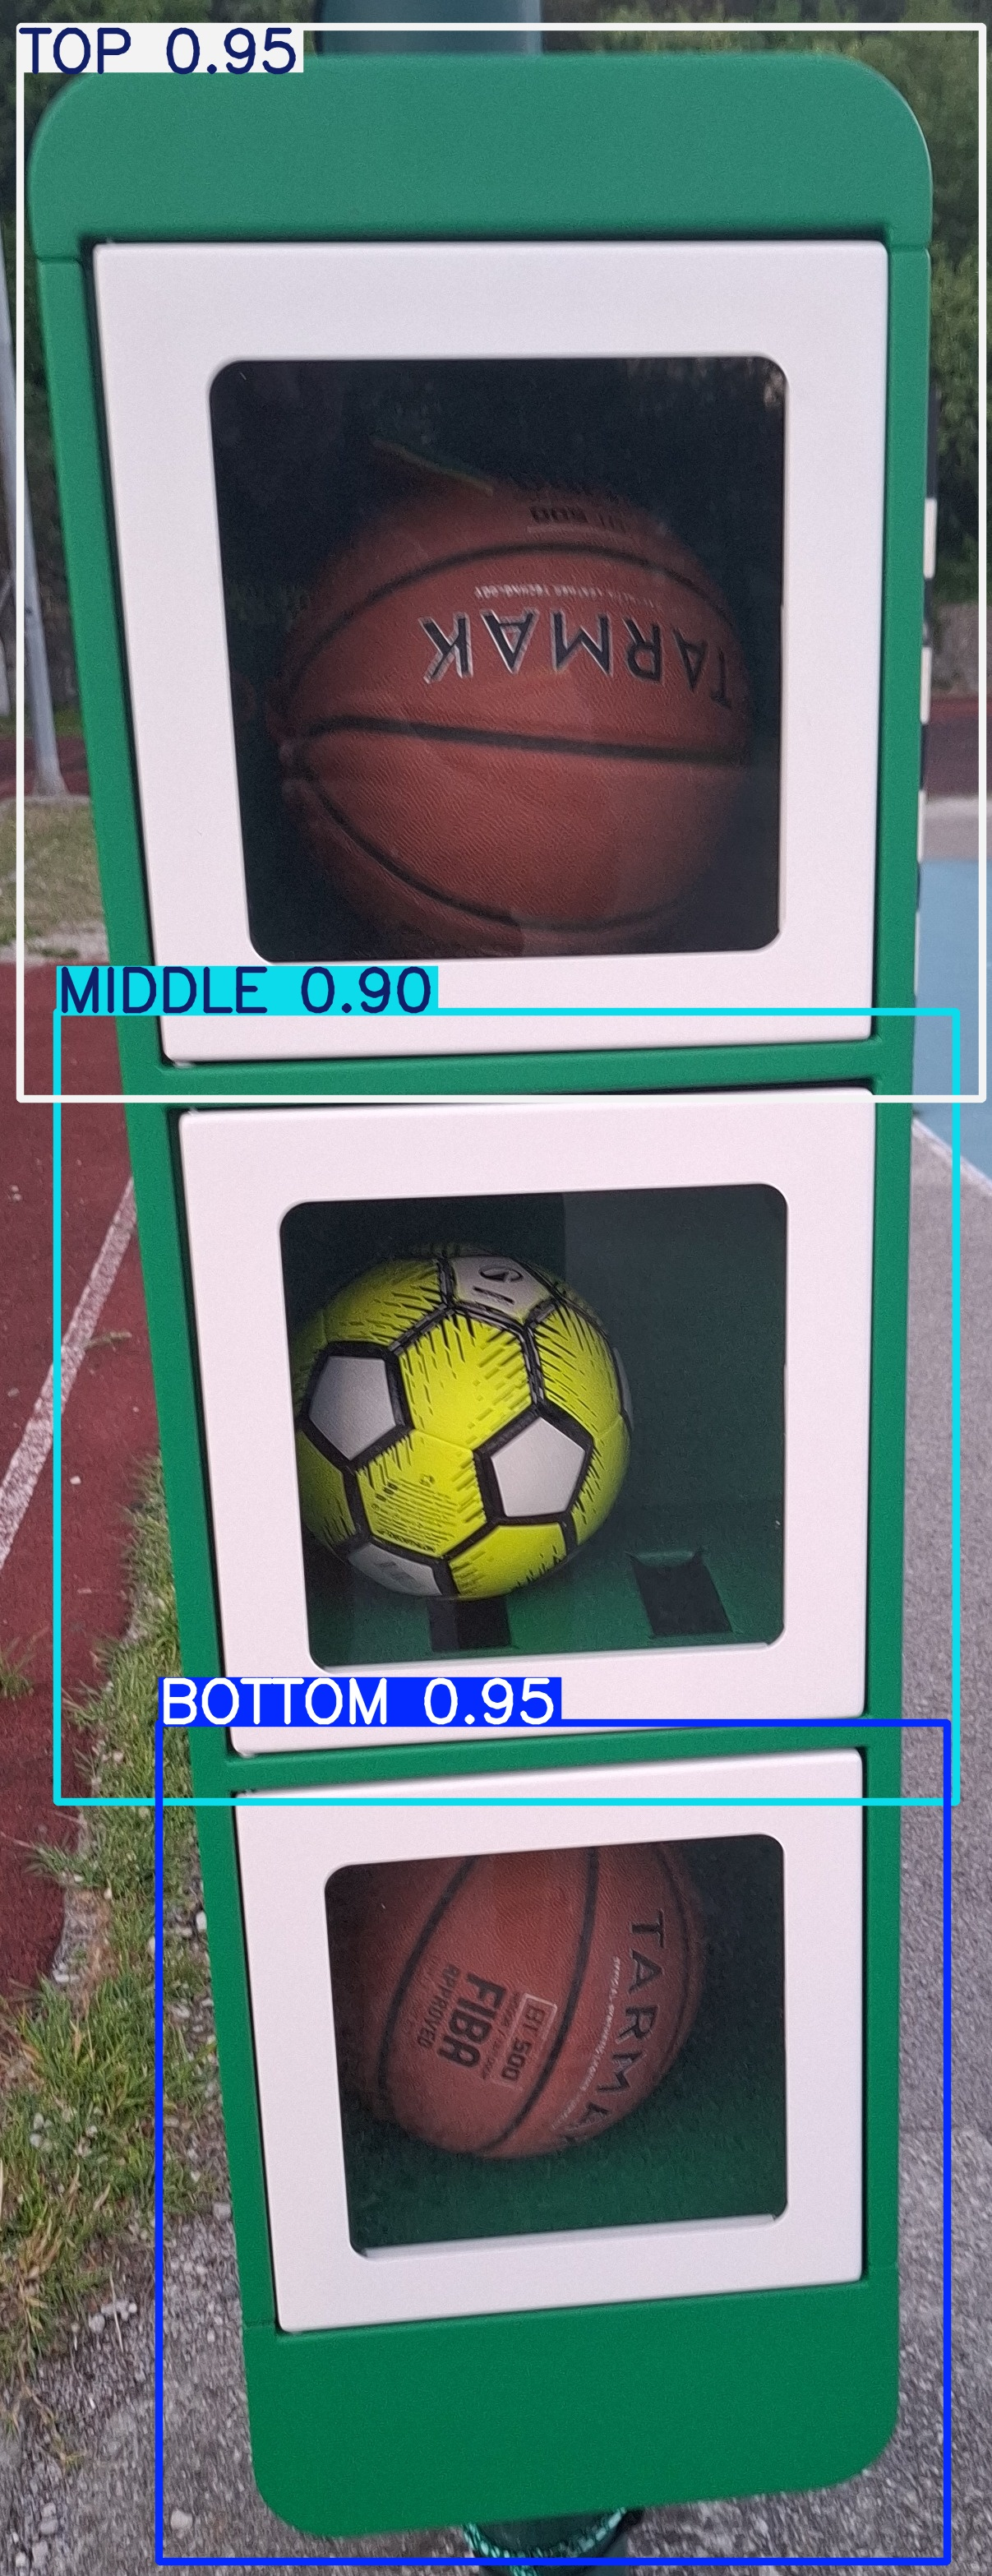

/content/runs/compartment_v0_1_val_predict/172f85f3-81d8-495e-a824-9a7ebfe95189.jpg


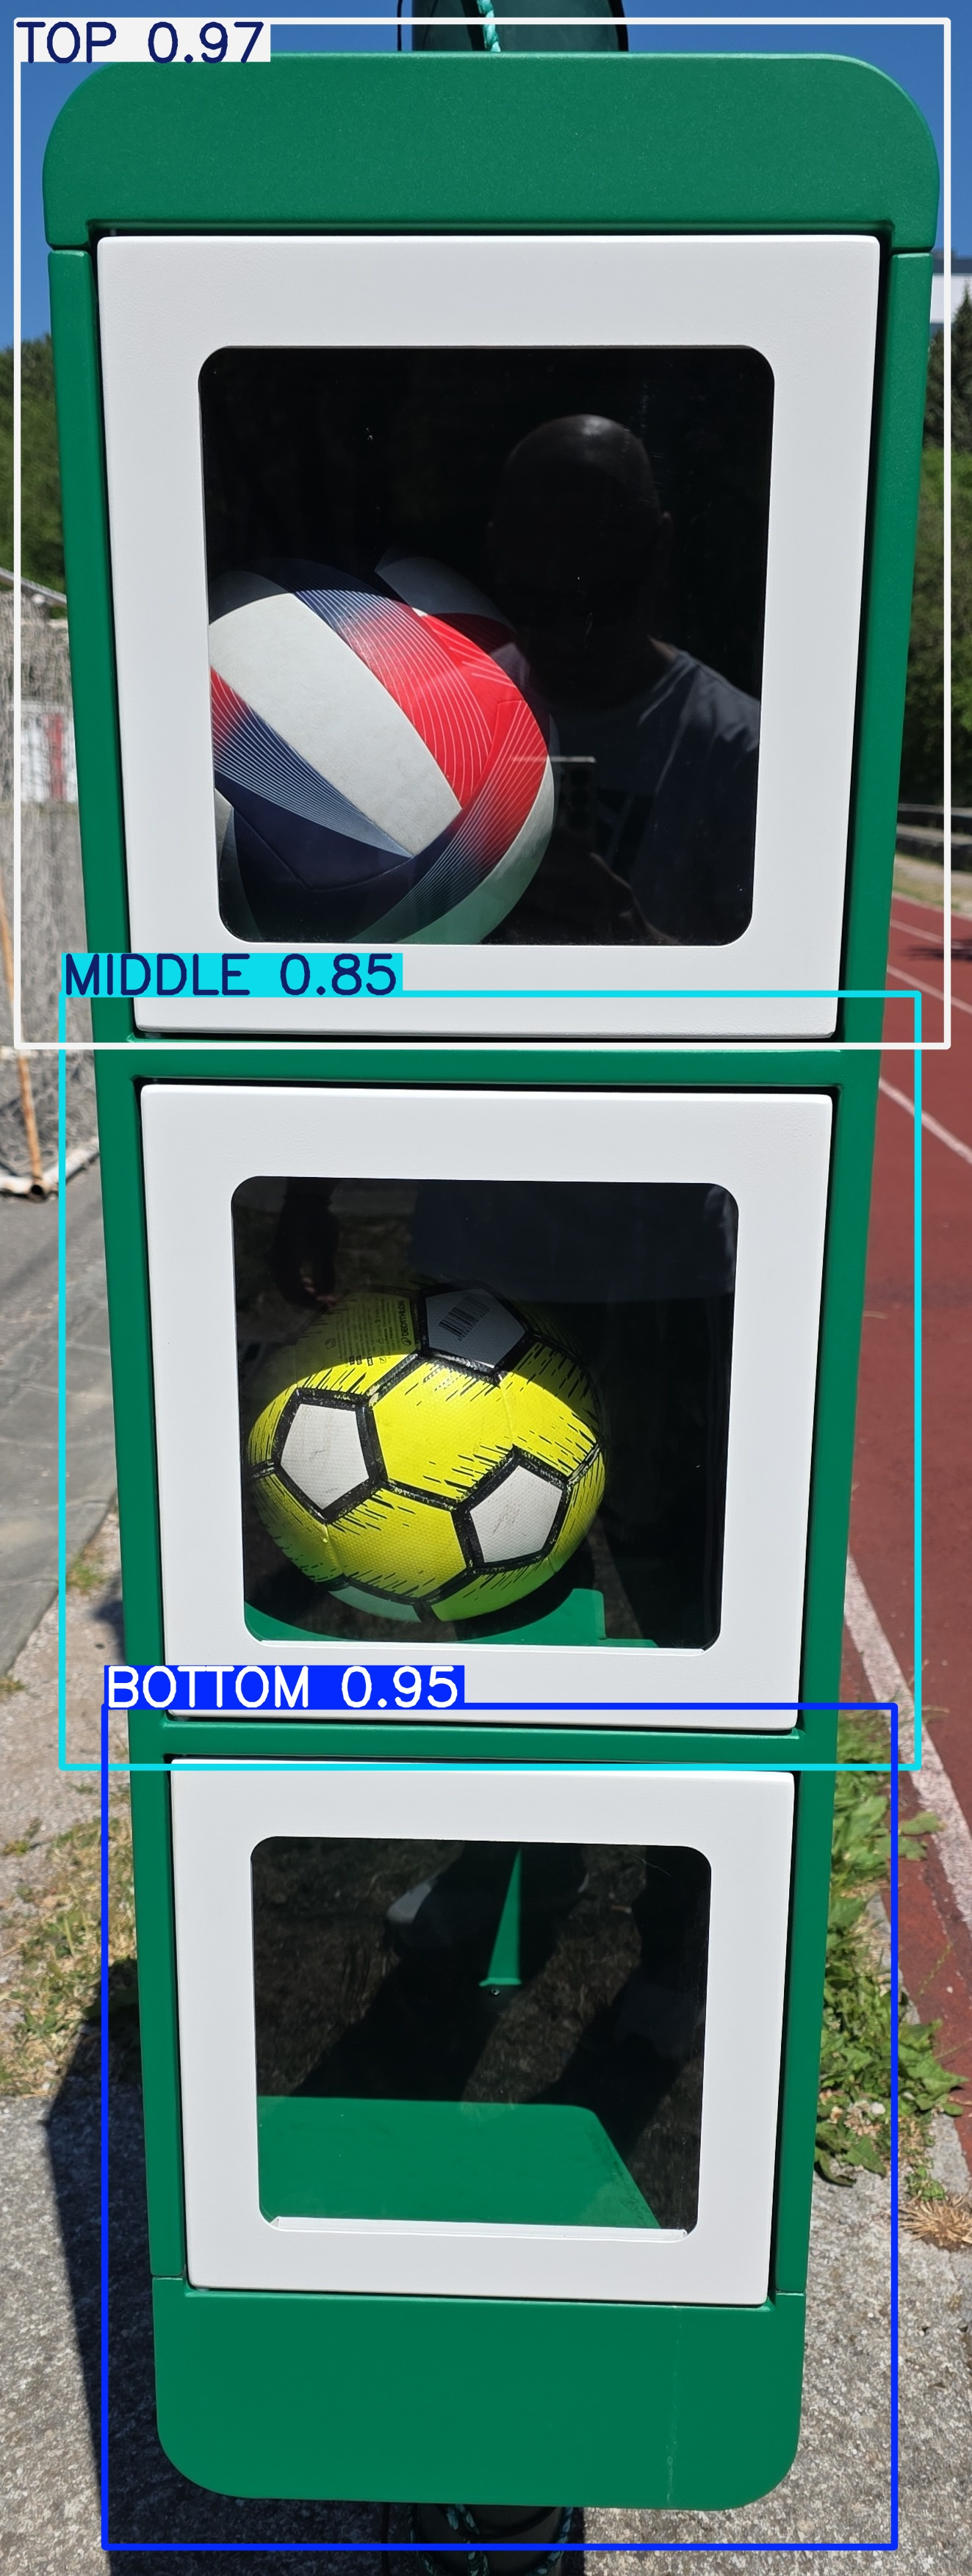

/content/runs/compartment_v0_1_val_predict/29f723db-cfcf-461b-bd0c-26e8bd5801f3.jpg


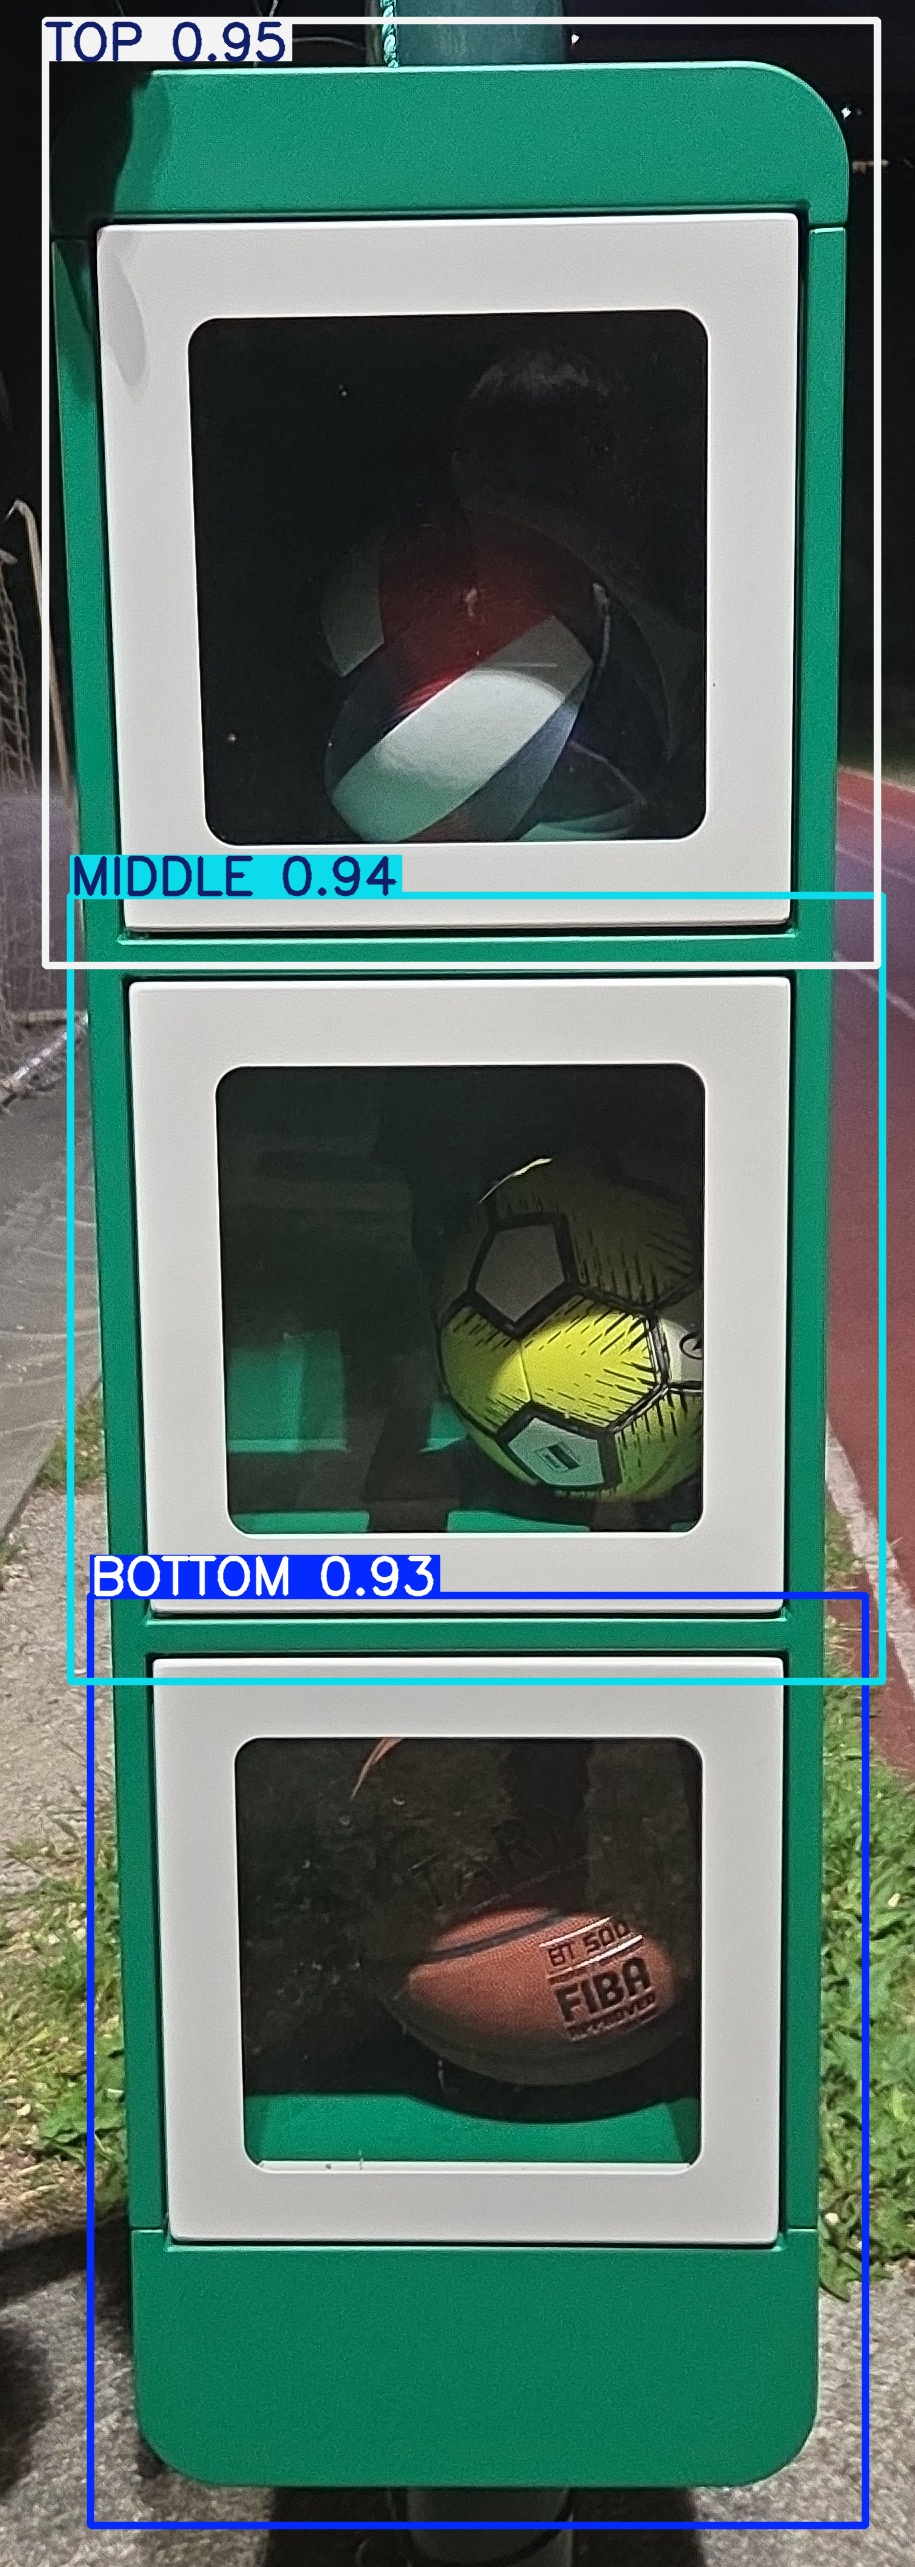

/content/runs/compartment_v0_1_val_predict/4101e24b-ba96-45ab-baa8-e037871da449.jpg


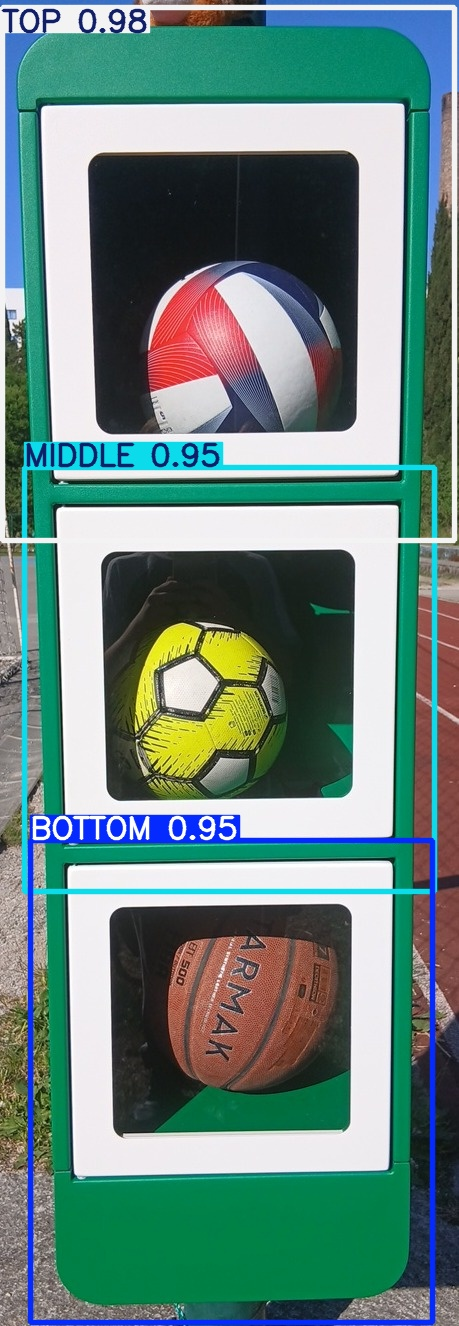

/content/runs/compartment_v0_1_val_predict/74e07669-0784-4756-b27a-c85a705eac0a.jpg


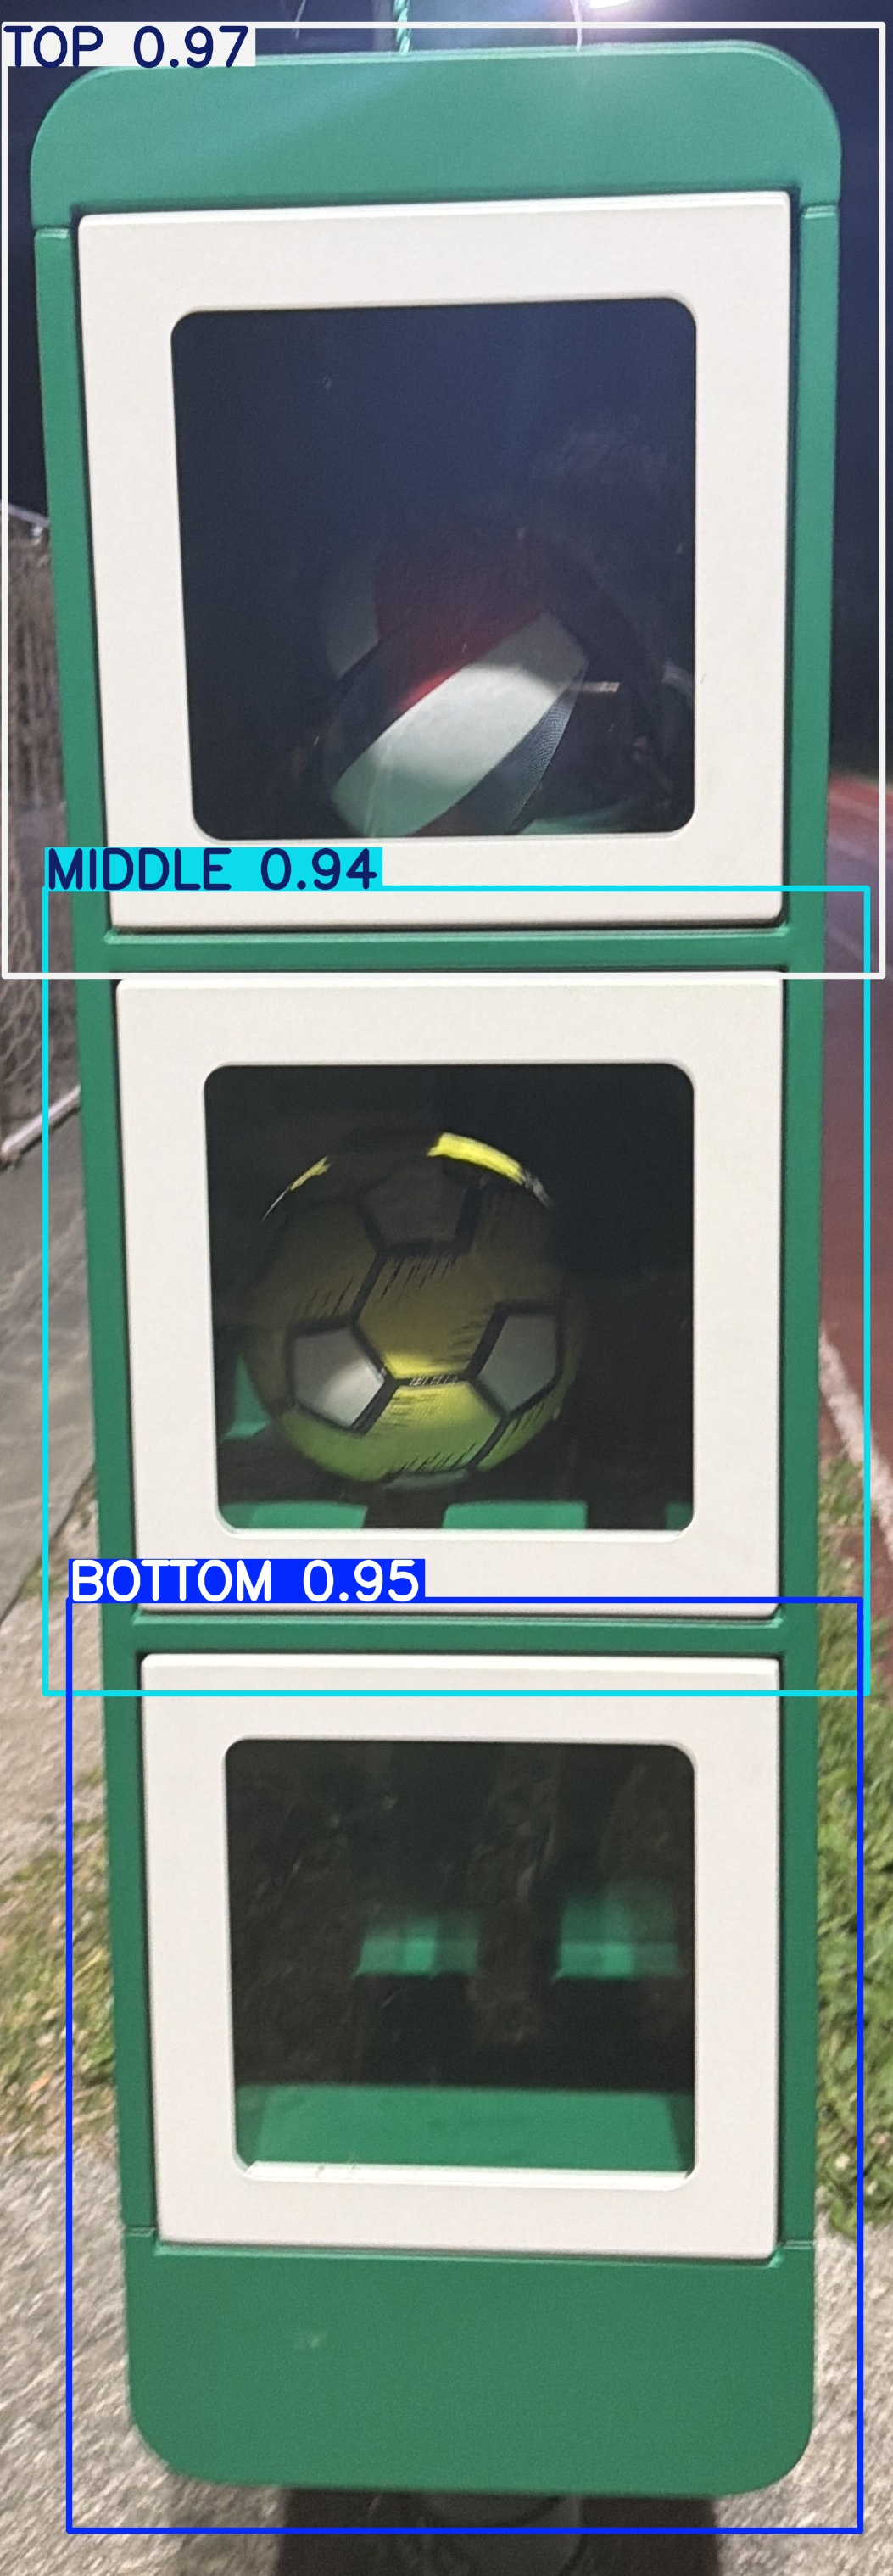

/content/runs/compartment_v0_1_val_predict/82a0b3db-788a-45ec-8216-a37529059887.jpg


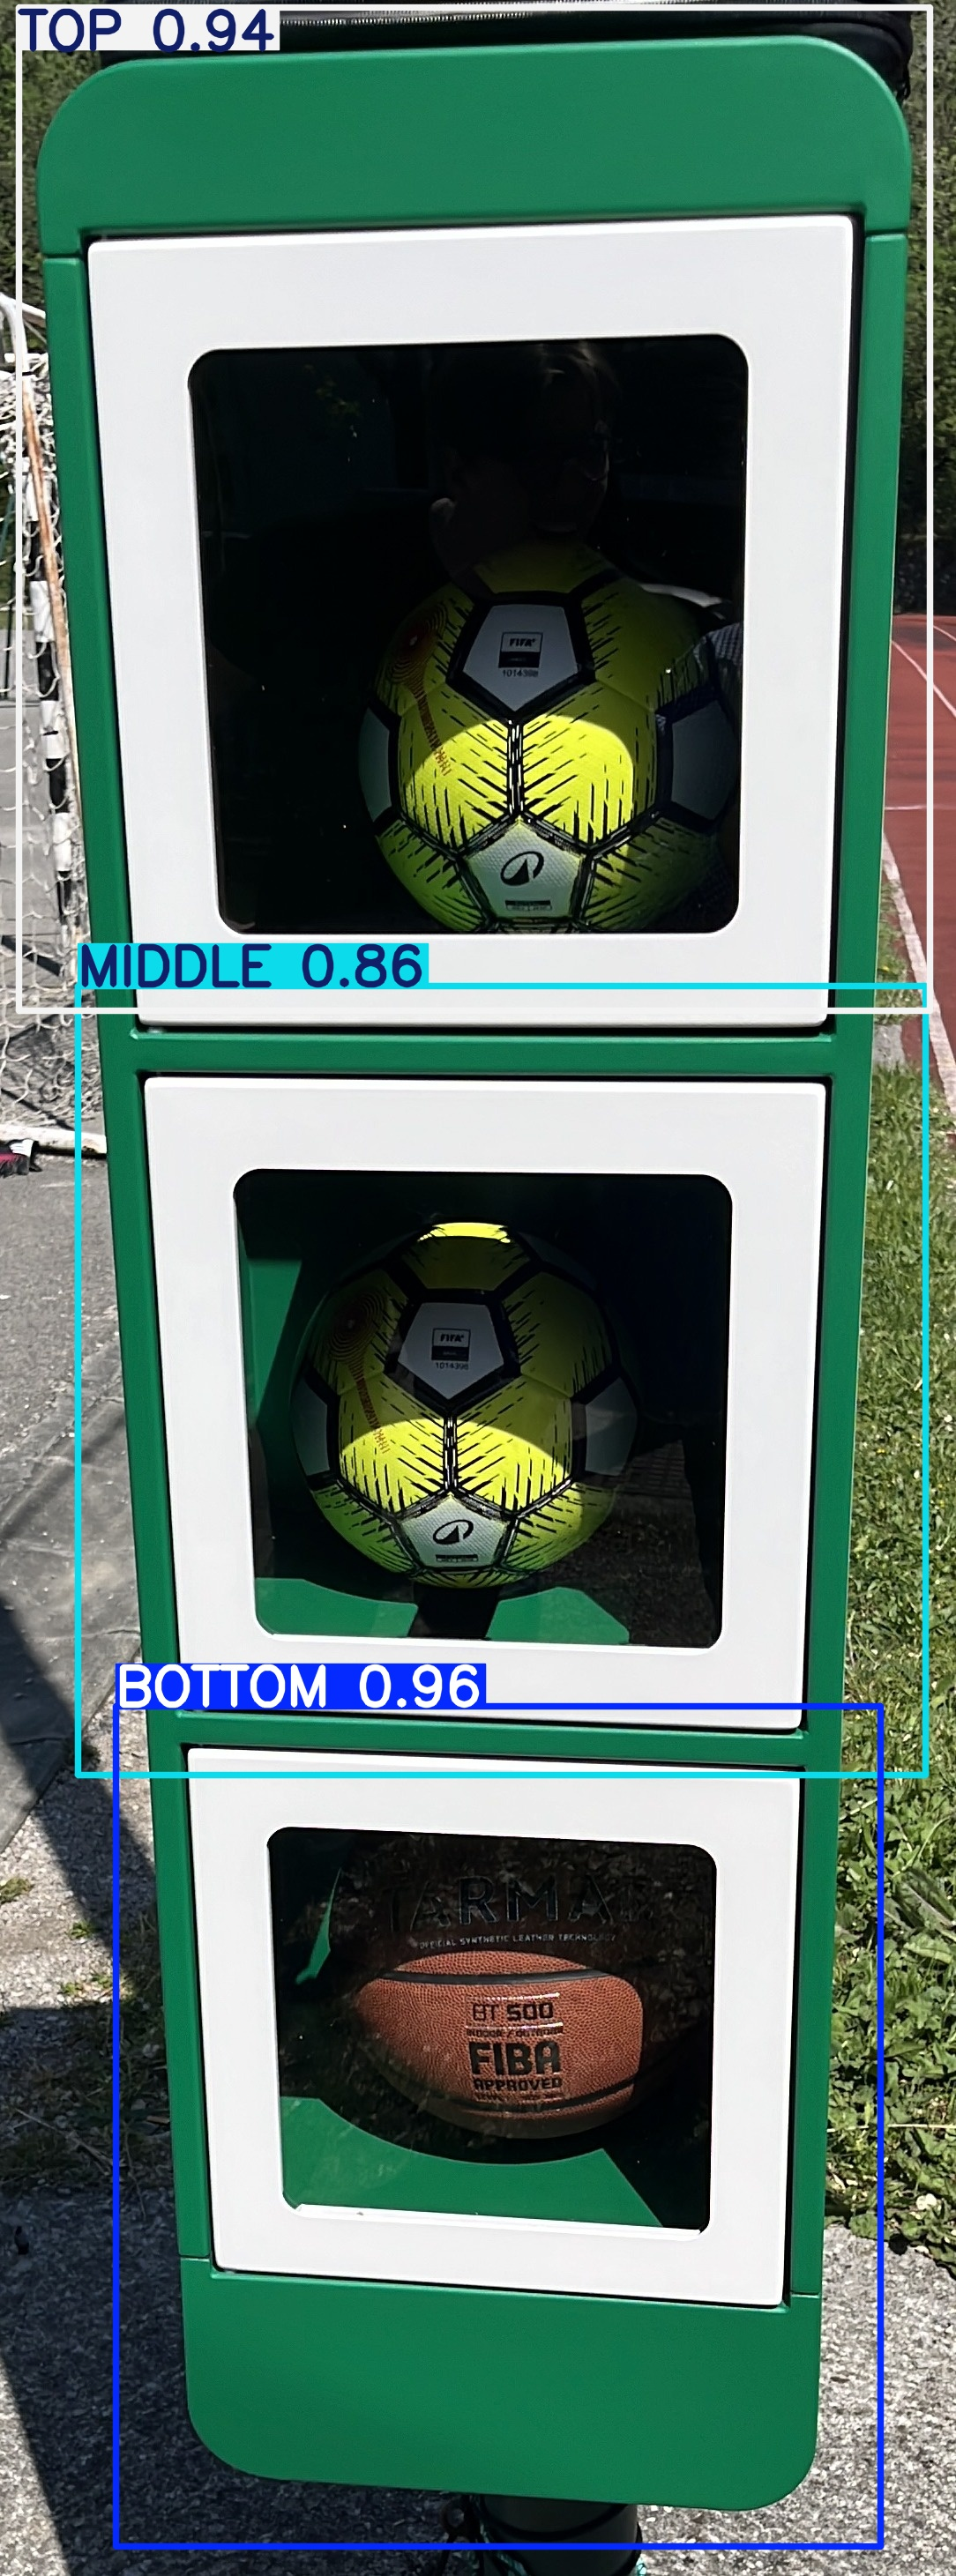

/content/runs/compartment_v0_1_val_predict/92ba9449-7d9a-4d57-ba19-3ad6e69536dc.jpg


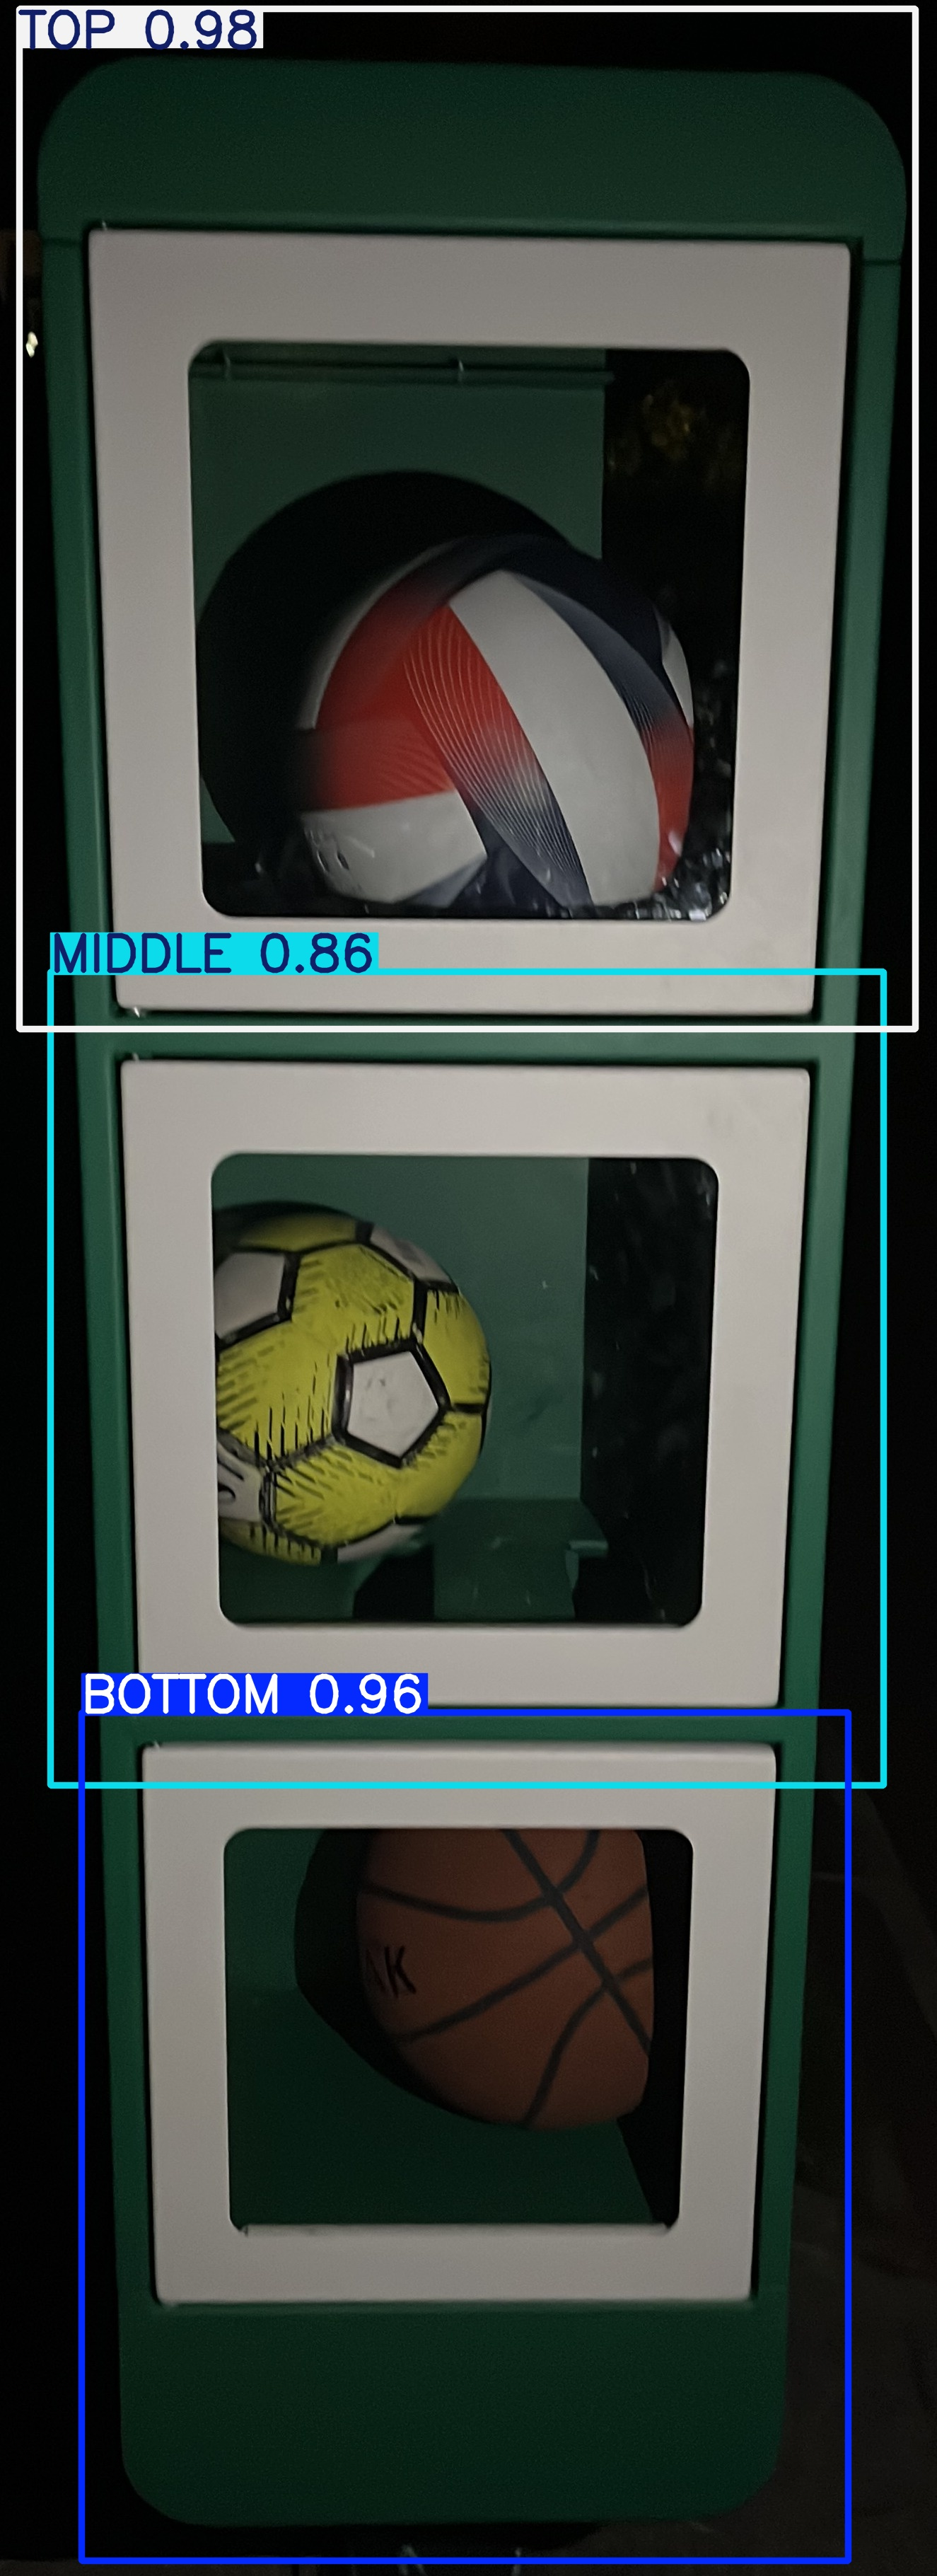

/content/runs/compartment_v0_1_val_predict/c7227055-2ea0-4928-9e59-06589cc72c62.jpg


In [9]:
import glob
from IPython.display import Image as IPImage, display
for p in sorted(glob.glob('/content/runs/compartment_v0_1_val_predict/*.jpg')):
    display(IPImage(filename=p, height=500))
    print(p)

## 7. Save Crops for Gear Detection Training Data

Run `--save-crop` on the **full training set** to generate compartment-region crops.
These crops become the input images for labelling gear (Stage 3).

Crops are saved to `runs/compartment_v0_1_crops/crops/TOP/`, `MIDDLE/`, `BOTTOM/`.

In [10]:
!yolo detect predict \
    model=/content/runs/compartment_v0_1/weights/best.pt \
    source=/content/data/train/images \
    save=True \
    save_crop=True \
    project=/content/runs \
    name=compartment_v0_1_crops

!echo 'TOP crops:' && ls /content/runs/compartment_v0_1_crops/crops/TOP | wc -l
!echo 'MIDDLE crops:' && ls /content/runs/compartment_v0_1_crops/crops/MIDDLE | wc -l
!echo 'BOTTOM crops:' && ls /content/runs/compartment_v0_1_crops/crops/BOTTOM | wc -l

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/61 /content/data/train/images/0417cf63-2b2c-4a72-bae0-7d063fd12603.jpg: 640x224 1 BOTTOM, 1 MIDDLE, 1 TOP, 51.6ms
image 2/61 /content/data/train/images/108e62fc-1356-4866-b6ed-5fcec26e17d7.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 51.9ms
image 3/61 /content/data/train/images/15193194-2a9f-4ffd-bac3-af42ad6f2395.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 9.4ms
image 4/61 /content/data/train/images/1ba7a675-3d77-427f-853d-a04f930d2d7b.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 8.2ms
image 5/61 /content/data/train/images/2522a87c-233f-4f3d-bf8e-0da56ea37d77.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 8.3ms
image 6/61 /content/data/train/images/253f471b-7a30-4655-a0dc-be0f51f920dd.jpg: 640x256 1 BOTTOM, 1 MIDDLE, 1 TOP, 7.8ms
image 7/61 /content/data/train/images/2664efb0-0dff-4e74-b02c-f28bc795cc05.jpg: 640x224 1 BOTTOM, 1 MIDDL

## 8. Export to ONNX

The production service uses ONNX Runtime — export with opset 20 to match existing models.

In [11]:
!yolo export \
    model=/content/runs/compartment_v0_1/weights/best.pt \
    format=onnx \
    imgsz=640 \
    opset=20

!ls -lh /content/runs/compartment_v0_1/weights/best.onnx

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/compartment_v0_1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 361ms
Prepared 4 packages in 1.59s
Installed 4 packages in 304ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimmin

## 9. Download Model + Crops

Two zips:
- `compartment_v0_1_model.zip` — ONNX model + training results → goes into `service/artifacts/compartment/0.1.0/`
- `compartment_v0_1_crops.zip` — compartment crops by class → used to build gear detection training data

In [12]:
# Model zip
!mkdir -p /content/compartment_v0_1_model
!cp /content/runs/compartment_v0_1/weights/best.onnx /content/compartment_v0_1_model/
!cp /content/runs/compartment_v0_1/weights/best.pt   /content/compartment_v0_1_model/
!cp /content/runs/compartment_v0_1/results.png       /content/compartment_v0_1_model/
!zip -r /content/compartment_v0_1_model.zip /content/compartment_v0_1_model

# Crops zip
!zip -r /content/compartment_v0_1_crops.zip /content/runs/compartment_v0_1_crops/crops

!echo 'Model zip:' && ls -lh /content/compartment_v0_1_model.zip
!echo 'Crops zip:' && ls -lh /content/compartment_v0_1_crops.zip

  adding: content/compartment_v0_1_model/ (stored 0%)
  adding: content/compartment_v0_1_model/best.onnx (deflated 13%)
  adding: content/compartment_v0_1_model/results.png (deflated 9%)
  adding: content/compartment_v0_1_model/best.pt (deflated 10%)
  adding: content/runs/compartment_v0_1_crops/crops/ (stored 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/ (stored 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/9f7909fc-e0cb-44f0-9f47-4b9af9b0f3bc.jpg (deflated 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/2522a87c-233f-4f3d-bf8e-0da56ea37d77.jpg (deflated 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/61599a33-5300-4cb3-a671-598e55a49e02.jpg (deflated 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/9a2590bd-6abf-4c9c-919f-28ac85f4de0a.jpg (deflated 0%)
  adding: content/runs/compartment_v0_1_crops/crops/MIDDLE/30590726-d463-44a7-ac06-7fa506efccbf.jpg (deflated 1%)
  adding: content/runs/compartment_v0_1_cr

In [13]:
# Copy both to Google Drive for safekeeping
!cp /content/compartment_v0_1_model.zip /content/gdrive/MyDrive/
!cp /content/compartment_v0_1_crops.zip /content/gdrive/MyDrive/
print('Saved to Google Drive.')

Saved to Google Drive.
